# Regression prediction

## Linear Regression

### 1. Import Libraries and Load the Dataset

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the cleaned dataset
california_data_cleaned = pd.read_csv('california_data_cleaned.csv')


### 2. Data Preparation

In [19]:
# Define the target and features
# Drop weakly correlated features
X = california_data_cleaned.drop(columns=['median_house_value'])
y = california_data_cleaned['median_house_value']


### 3. Split the Data

In [20]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 4. Train a Linear Regression Model

In [21]:
# Initialize the linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)


LinearRegression()

### 5. Evaluate the Model

In [27]:
# Make predictions
import numpy as np


y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

residuals = y_test - y_pred
rse = np.sqrt(np.sum(residuals**2) / (len(y_test) - len(X_test.columns) - 1))
print("Residual Standard Error:", rse)



Mean Squared Error: 4274312456.683235
R-squared: 0.6495617385333996
Residual Standard Error: 65494.424705135745


## Visualization :

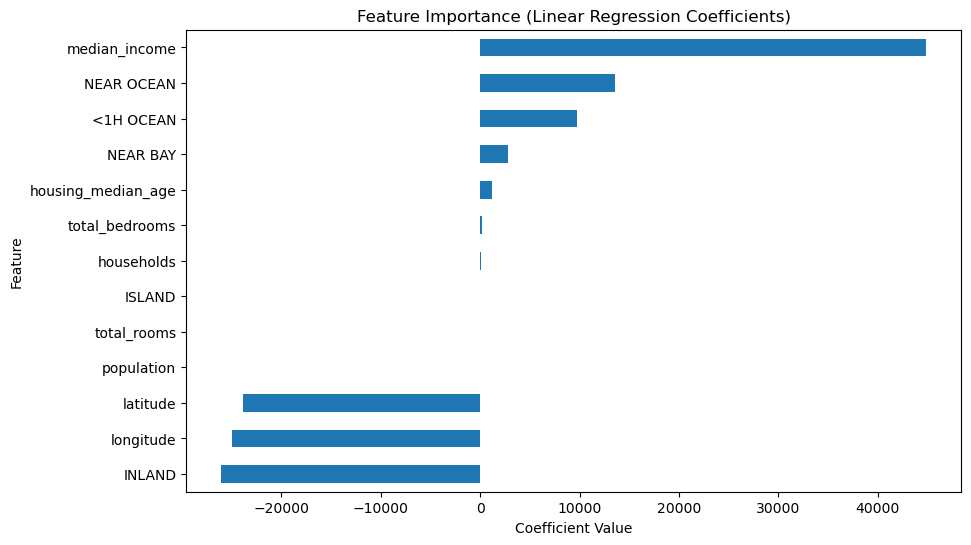

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot feature importance (coefficients)
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients_sorted = coefficients.sort_values()

plt.figure(figsize=(10, 6))
coefficients_sorted.plot(kind='barh')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()



#### Most Influential Positive Features:
- **`median_income`**: This feature has the largest positive coefficient, indicating that higher median income strongly correlates with higher house values. It's the most important feature for your model.
- **Proximity to water bodies** (`NEAR OCEAN`, `<1H OCEAN`, `NEAR BAY`): These features have positive coefficients, showing that homes closer to the ocean or bay tend to have higher values.

#### Negative Features:
- **`INLAND`**: This feature has the largest negative coefficient. Being inland correlates strongly with lower house values, which makes sense if proximity to the coast increases desirability.
- **Geographic Features** (`latitude`, `longitude`): These have negative coefficients, suggesting specific geographic locations (likely further south or east) are associated with lower house values.

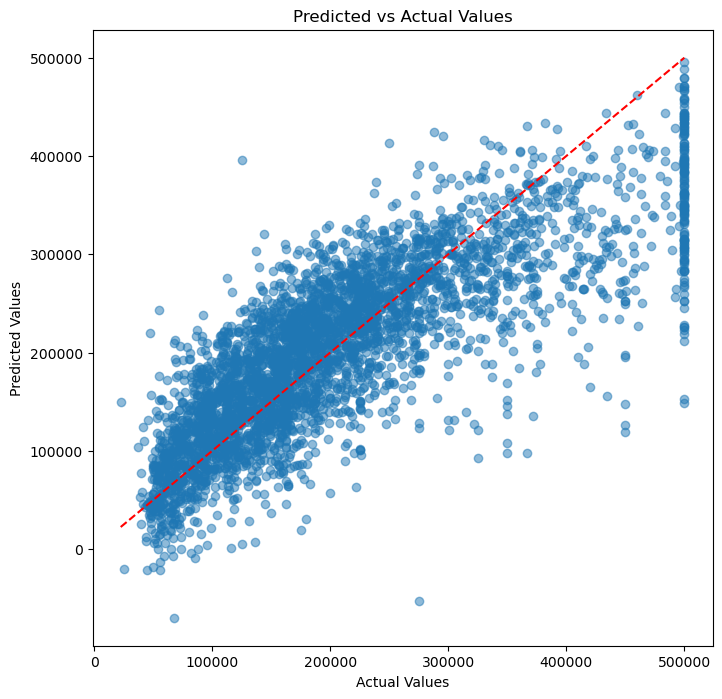

In [ ]:

# Predicted vs Actual
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Ideal line
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()





### Systematic Errors:
- At higher house values (e.g., **300,000 and above**), the model tends to underpredict (predictions are lower than actual values).
- This suggests that the linear regression model may not be flexible enough to capture the complexity of the relationships in the data, especially for expensive houses.


## Polynomial Linear Regression

### 1. Data Preparation

In [30]:

from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures(degree=2)


X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

### 2. Train a Linear Regression Model

In [31]:
model = LinearRegression()


model.fit(X_poly_train, y_train)


y_pred_poly = model.predict(X_poly_test)

### 3. Evaluate the Model

In [35]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("\nPolynomial Linear Regression")
print(f"  Mean Squared Error: {mse_poly:.4f}")
print(f"  R² Score: {r2_poly:.4f}")




Polynomial Linear Regression
  Mean Squared Error: 3347378508.6473
  R² Score: 0.7256


## Random Forest Regressor

###  Train a Random Forst Regressor

In [14]:
# Initialize Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor


rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_regressor.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

###  Evaluate the Model

In [16]:
# Predictions
y_pred = rf_regressor.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

import numpy as np
rmse = np.sqrt(3565712298.1230)
print("RMSE:", rmse)

variance = california_data_cleaned['median_house_value'].var()
print("Variance:", variance)




Mean Squared Error: 2242724131.017114
R-squared: 0.8161256685402223
RMSE: 59713.58554067073
Variance: 12236609310.453745


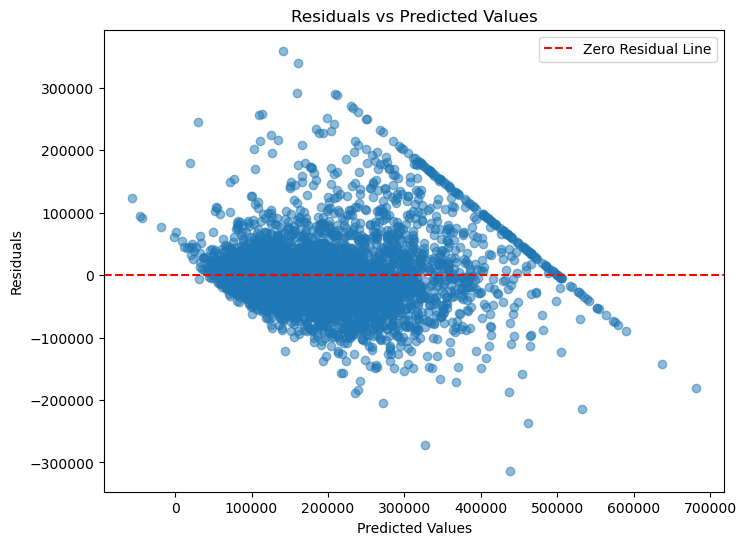

In [36]:
# Residuals Calculation
residuals = y_test - y_pred

# Plot Residuals
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', label='Zero Residual Line')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.show()


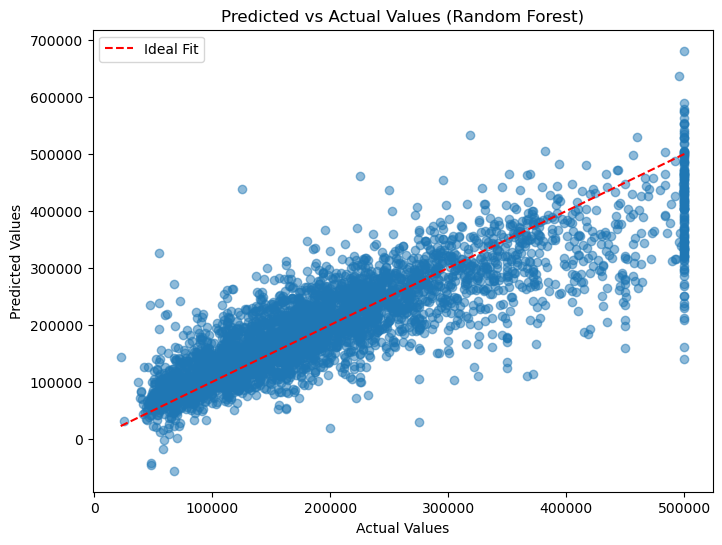

In [38]:
# Predicted vs Actual Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title('Predicted vs Actual Values (Random Forest)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()


### Interpretation


The Random Forest model performs well with an R² of 81.7% and an RMSE of ~60,000.
The RMSE suggests that while predictions are relatively accurate, they may still be off by tens of thousands in absolute terms. This is acceptable because the house values are in the hundreds of thousands or more.

Variance comparison: The MSE being much lower than the variance confirms the model is doing well, as it significantly reduces the error compared to a naive mean-based prediction.

## Interpret the Results 


The model struggles to predict large house values accurately because these high-value instances are underrepresented in the dataset. This imbalance leads to insufficient training data for the model to learn patterns associated with expensive houses, resulting in higher residuals and underprediction for these cases. To improve performance on larger values, additional data or targeted techniques to balance the dataset might be required.
